# Data Exploration

## Download Datasets

In [3]:
from tdc.single_pred import Tox
from tdc.multi_pred.dti import DTI  
from tdc.utils import retrieve_label_name_list

DATA_PATH = '../data'

# ============================================================
# TOXICITY DATASETS (core focus of the project)
# ============================================================

# 1. AMES — 7,255 molecules ★ START HERE
# Does this drug cause DNA mutations? (cancer risk)
# Binary classification. Clean, well-studied, good size for GNNs.
data_ames = Tox(name='AMES', path=DATA_PATH)
split_ames = data_ames.get_split()

# 2. hERG_Karim — 13,445 molecules
# Does this drug block the heart's hERG potassium channel? (fatal arrhythmia risk)
# Binary classification. Largest single-target toxicity dataset here.
data_herg = Tox(name='hERG_Karim', path=DATA_PATH)
split_herg = data_herg.get_split()

# 3. ClinTox — 1,484 molecules
# Did this drug fail clinical trials due to toxicity, or get FDA approved?
# Binary classification. Real-world outcome, not a lab assay.
data_clintox = Tox(name='ClinTox', path=DATA_PATH)
split_clintox = data_clintox.get_split()

# 4. Tox21 — 7,831 molecules × 12 targets
# US government screen across 12 toxicity pathways (nuclear receptors, stress response)
# Multi-label classification. Each molecule gets 12 binary labels.
label_list = retrieve_label_name_list('Tox21')
data_tox21 = Tox(name='Tox21', label_name=label_list[0], path=DATA_PATH)
split_tox21 = data_tox21.get_split()

# 5. DILI — 475 molecules
# Does this drug cause liver injury? #1 reason drugs get pulled from market.
# Binary classification. Very small — might be too tiny for GNNs.
data_dili = Tox(name='DILI', path=DATA_PATH)
split_dili = data_dili.get_split()

# 6. LD50_Zhu — 7,385 molecules
# What dose kills 50% of test organisms? (acute toxicity)
# Regression, not classification. Predict a continuous log-dose value.
data_ld50 = Tox(name='LD50_Zhu', path=DATA_PATH)
split_ld50 = data_ld50.get_split()

# ============================================================
# BINDING SELECTIVITY DATASETS (stretch goal per proposal)
# ============================================================

# 7. DAVIS — 30,056 drug-target pairs (68 drugs × 442 kinase targets)
# How strongly does this drug bind to each kinase protein?
# Regression (Kd affinity). Same drugs across many targets = selectivity data.
# Trains on CPU in ~30-60 min.
data_davis = DTI(name='DAVIS', path=DATA_PATH)
split_davis = data_davis.get_split()

# 8. KIBA — 118,254 drug-target pairs (2,111 drugs × 229 targets)
# Same idea as DAVIS but much larger. Probably needs a GPU.
# Only use if DAVIS feels too small.
data_kiba = DTI(name='KIBA', path=DATA_PATH)
split_kiba = data_kiba.get_split()

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


## Dataset Overview

In [4]:
print(split_ames.keys())
print(split_ames['train'].keys())
print(type(split_ames['train']))
print(split_ames['train'].head())

dict_keys(['train', 'valid', 'test'])
Index(['Drug_ID', 'Drug', 'Y'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
  Drug_ID                                               Drug  Y
0  Drug 1       O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2  1
1  Drug 2  O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...  0
2  Drug 3                          [N-]=[N+]=CC(=O)NCC(=O)NN  1
3  Drug 4                          [N-]=[N+]=C1C=NC(=O)NC1=O  1
4  Drug 6          CCCCN(CC(O)C1=CC(=[N+]=[N-])C(=O)C=C1)N=O  1


In [5]:
from rdkit import Chem
from torch_geometric.data import Data
import torch

def smiles_to_graph(smiles):
    """Convert a SMILES string to a PyTorch Geometric graph."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Nodes: one per atom
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),        # element: C=6, N=7, O=8, etc.
            atom.GetDegree(),           # number of bonds
            atom.GetFormalCharge(),      # +1, -1, 0
            int(atom.GetIsAromatic()),   # aromatic ring? 1/0
        ])

    # Edges: one per bond (both directions)
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])  # undirected graph

    x = torch.tensor(atom_features, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index)


# Example: first row from your dataframe
smiles = split_ames['train']['Drug'][0]
g = smiles_to_graph(smiles)
print(g)

Data(x=[23, 4], edge_index=[2, 54])


In [6]:
from torch_geometric.loader import DataLoader

def build_dataset(df):
    """Convert a TDC dataframe to a list of PyG Data objects."""
    graphs = []
    for _, row in df.iterrows():
        g = smiles_to_graph(row['Drug'])
        if g is not None:
            g.y = torch.tensor([row['Y']], dtype=torch.float)
            graphs.append(g)
    return graphs

train_graphs = build_dataset(split_ames['train'])
val_graphs = build_dataset(split_ames['valid'])
test_graphs = build_dataset(split_ames['test'])

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32)
test_loader = DataLoader(test_graphs, batch_size=32)

# Check one batch
batch = next(iter(train_loader))
print(batch)

DataBatch(x=[508, 4], edge_index=[2, 1090], y=[32], batch=[508], ptr=[33])


## Graph Visualisation

Done


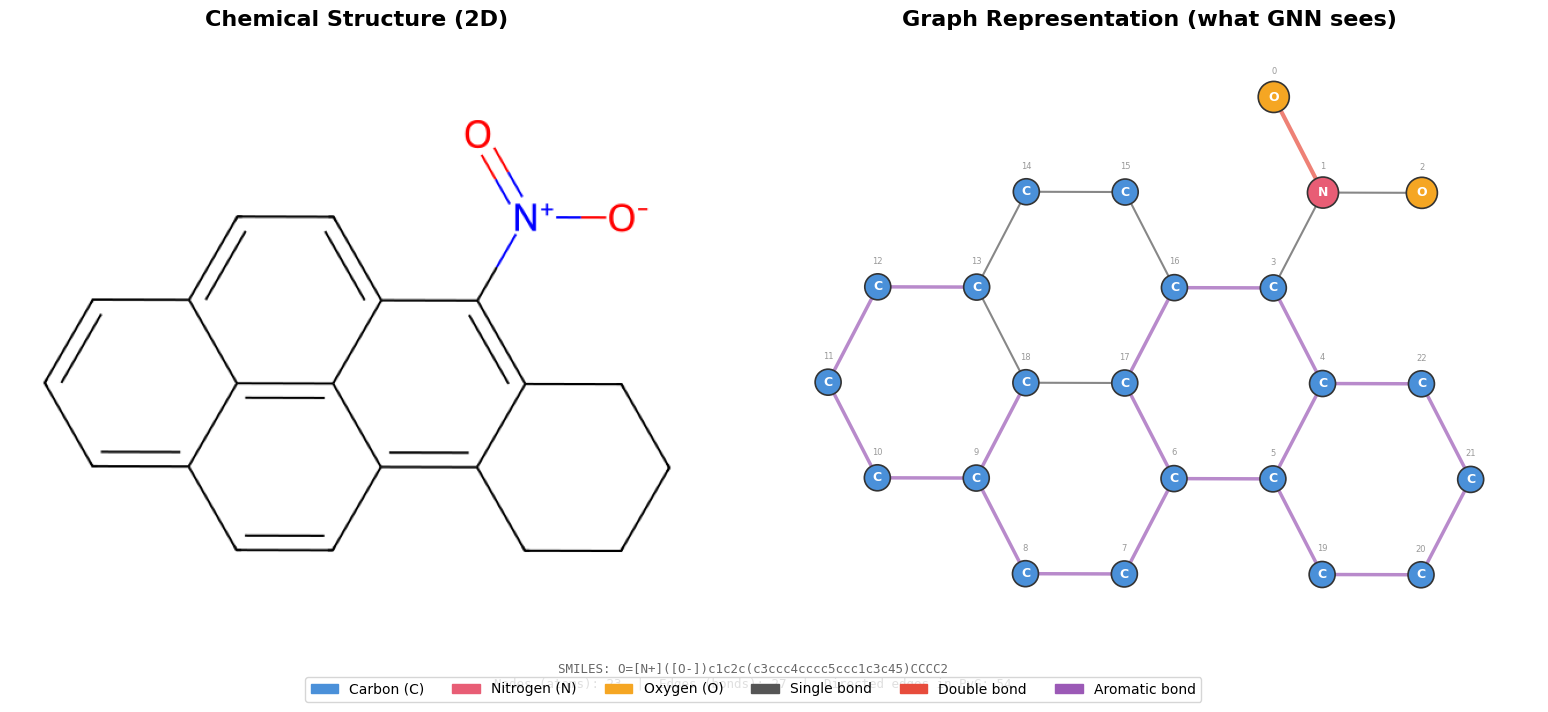

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from rdkit import Chem
from rdkit.Chem import Draw, AllChem

mol = Chem.MolFromSmiles(smiles)
AllChem.Compute2DCoords(mol)

# Build networkx graph from molecule
G = nx.Graph()
conf = mol.GetConformer()

atom_colors_map = {6: '#4A90D9', 7: '#E85D75', 8: '#F5A623', 16: '#F7DC6F', 9: '#82E0AA', 17: '#82E0AA'}
atom_labels_map = {6: 'C', 7: 'N', 8: 'O', 16: 'S', 9: 'F', 17: 'Cl'}
bond_style_map = {Chem.rdchem.BondType.SINGLE: '-', Chem.rdchem.BondType.DOUBLE: '=', Chem.rdchem.BondType.AROMATIC: '~'}

node_colors = []
node_labels = {}
node_sizes = []

for atom in mol.GetAtoms():
    idx = atom.GetIdx()
    num = atom.GetAtomicNum()
    pos = conf.GetAtomPosition(idx)
    G.add_node(idx, pos=(pos.x, pos.y))
    node_colors.append(atom_colors_map.get(num, '#CCCCCC'))
    node_labels[idx] = atom_labels_map.get(num, atom.GetSymbol())
    node_sizes.append(500 if num != 6 else 350)

edge_colors = []
edge_widths = []
for bond in mol.GetBonds():
    i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
    bt = bond.GetBondType()
    G.add_edge(i, j)
    if bt == Chem.rdchem.BondType.DOUBLE:
        edge_colors.append('#E74C3C')
        edge_widths.append(3.0)
    elif bt == Chem.rdchem.BondType.AROMATIC:
        edge_colors.append('#9B59B6')
        edge_widths.append(2.5)
    else:
        edge_colors.append('#555555')
        edge_widths.append(1.5)

pos = nx.get_node_attributes(G, 'pos')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# Left: chemical structure
img = Draw.MolToImage(mol, size=(600, 500))
axes[0].imshow(img)
axes[0].set_title('Chemical Structure (2D)', fontsize=16, fontweight='bold', pad=15)
axes[0].axis('off')

# Right: graph representation
ax = axes[1]
ax.set_facecolor('#FAFAFA')

nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths, alpha=0.7)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                       edgecolors='#333333', linewidths=1.2)
nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax, font_size=9, font_weight='bold', font_color='white')

# Node index labels (small, offset)
offset_pos = {k: (v[0], v[1] + 0.35) for k, v in pos.items()}
idx_labels = {i: str(i) for i in G.nodes()}
nx.draw_networkx_labels(G, offset_pos, labels=idx_labels, ax=ax, font_size=6, font_color='#999999')

ax.set_title('Graph Representation (what GNN sees)', fontsize=16, fontweight='bold', pad=15)
ax.axis('off')

# Legend
legend_items = [
    mpatches.Patch(color='#4A90D9', label='Carbon (C)'),
    mpatches.Patch(color='#E85D75', label='Nitrogen (N)'),
    mpatches.Patch(color='#F5A623', label='Oxygen (O)'),
    mpatches.Patch(color='#555555', label='Single bond'),
    mpatches.Patch(color='#E74C3C', label='Double bond'),
    mpatches.Patch(color='#9B59B6', label='Aromatic bond'),
]
fig.legend(handles=legend_items, loc='lower center', ncol=6, fontsize=10,
           frameon=True, facecolor='white', edgecolor='#CCCCCC', bbox_to_anchor=(0.5, -0.02))

# Stats annotation
stats_text = (
    f"SMILES: {smiles}\n"
    f"Nodes (atoms): {mol.GetNumAtoms()}  |  "
    f"Edges (bonds): {mol.GetNumBonds()}  |  "
    f"Directed edges in PyG: {mol.GetNumBonds() * 2}"
)
fig.text(0.5, 0.01, stats_text, ha='center', fontsize=9, color='#666666', family='monospace')

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.savefig('../plots/mol_graph.png', dpi=200, bbox_inches='tight', facecolor='white')
print("Done")

## Graph Neural Network
https://projects.volkamerlab.org/teachopencadd/talktorials/T035_graph_neural_networks.html

In [8]:
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        x = torch.relu(x)
        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x.squeeze(-1)

In [9]:
from torch_geometric.nn import GINConv, global_add_pool
from torch.nn import Sequential, Linear, BatchNorm1d, ReLU

class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GIN, self).__init__()
        self.conv1 = GINConv(
            Sequential(
                Linear(in_channels, hidden_channels), 
                BatchNorm1d(hidden_channels), 
                ReLU(), 
                Linear(hidden_channels, hidden_channels), 
                ReLU())
        )
        self.conv2 = GINConv(
            Sequential(
                Linear(hidden_channels, hidden_channels), 
                BatchNorm1d(hidden_channels), 
                ReLU(), 
                Linear(hidden_channels, hidden_channels), 
                ReLU()
            )
        )
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        x = torch.relu(x)
        x = global_add_pool(x, batch)
        x = self.lin(x)
        return x.squeeze(-1)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
# model = GCN(train_graphs[0].num_node_features, 16, 1).to(device)
model = GIN(train_graphs[0].num_node_features, 16, 1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

model.train()
for epoch in range(200):
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.binary_cross_entropy_with_logits(out, batch.y.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_graphs):.4f}")

cuda


In [ ]:
import numpy as np

model.eval()
loss = torch.nn.MSELoss()
test_loss = 0
test_target = np.empty((0))
test_y_target = np.empty((0))
for d in test_loader:
    d.to(device)
    out = model(d.x, d.edge_index, d.batch)
    # NOTE
    # out = out.view(d.y.size())
    l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
    test_loss += l / len(test_loader)
    # save prediction vs ground truth values for plotting
    test_target = np.concatenate((test_target, out.detach().cpu().numpy()))
    test_y_target = np.concatenate((test_y_target, d.y.detach().cpu().numpy()))

print(f'Test MAE: {np.mean(np.abs(test_target - test_y_target)):.4f}')


Test MAE: 1.2898
